# **Assignment No - 8**

---

**Name**- Vaishnavi Krishnat Phalle.
**Roll No**-EN23107096.
**Class**-AIDS(B).
**Batch**- A.

---

**Title** -
Develop a Gradient Boosting regression model to predict wine quality based on physicochemical properties. Handle missing values, perform feature scaling, and evaluate the model using MSE, MAE, RMSE, and R-squared. Dataset: Wine Quality Dataset (UCI).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("winequalityN.csv")
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [ ]:
RANDOM_STATE = 42

In [ ]:
df.isna().sum()


,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
X = df.drop('quality', axis=1)
X = pd.get_dummies(X, columns=['type'], drop_first=True)
y = df['quality']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train.shape, X_test.shape

((5197, 12), (1300, 12))

In [ ]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_imputed)

X_test_imputed = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imputed)

In [ ]:
gbr = GradientBoostingRegressor(random_state=RANDOM_STATE)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4],
    'min_samples_split': [2, 5]
}

In [ ]:
grid = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

In [ ]:
grid.fit(X_train_scaled, y_train)
grid.best_params_

Fitting 5 folds for each of 16 candidates, totalling 80 fits


{'learning_rate': 0.1,
 'max_depth': 4,
 'min_samples_split': 5,
 'n_estimators': 200}

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
print(f"MSE  : {mse:.4f}")

MSE  : 0.3853


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE  : {mae:.4f}")

MAE  : 0.4824


In [ ]:
rmse = np.sqrt(mse)
print(f"RMSE : {rmse:.4f}")

RMSE : 0.6208


In [ ]:
r2 = r2_score(y_test, y_pred)
print(f"R^2  : {r2:.4f}")

R^2  : 0.4609


In [ ]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

importance_df.head(10)

,feature,importance
10,alcohol,0.335532
1,volatile acidity,0.141753
5,free sulfur dioxide,0.094446
9,sulphates,0.072618
3,residual sugar,0.067233
6,total sulfur dioxide,0.062877
7,density,0.048149
8,pH,0.047556
4,chlorides,0.044929
2,citric acid,0.044837


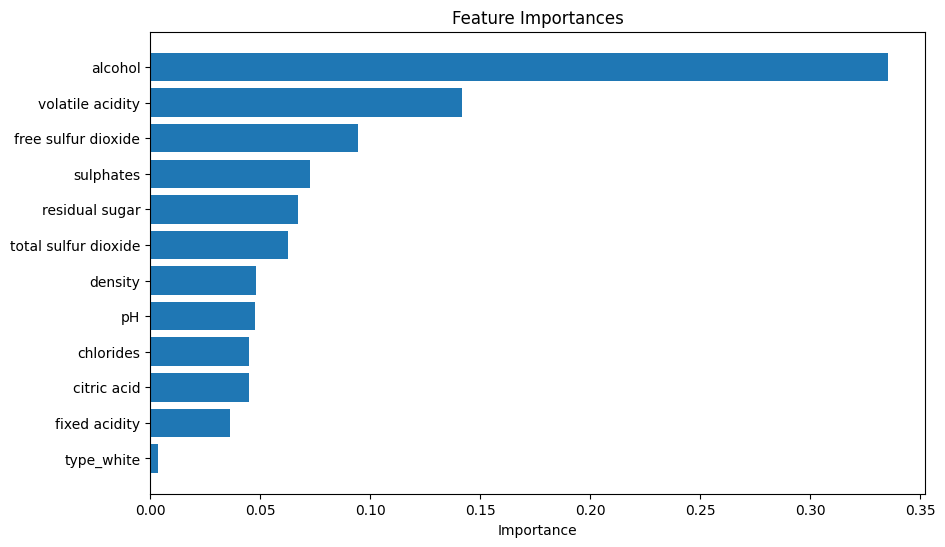

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.show()

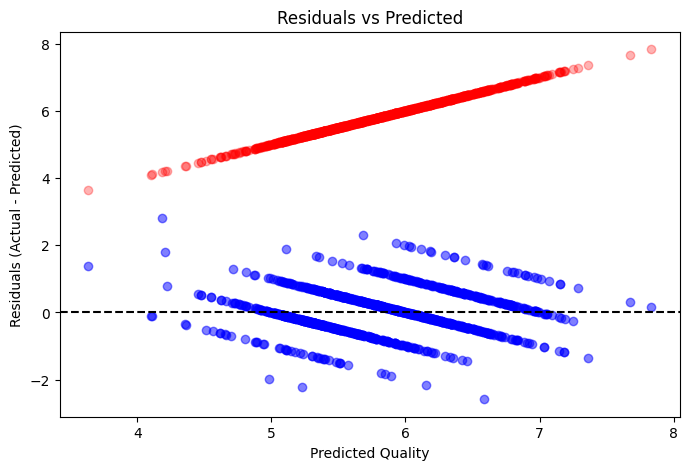

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, color='blue', alpha=0.5, label='Residuals')
plt.scatter(y_pred, y_pred, color='red', alpha=0.3, label='Predicted')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted Quality")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.show()